In [1]:
import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path

##########################################################
# Initialize parameters  
##########################################################

# 2 runs of set1-7 before disabling hot channels
#filename = "../results/set1-7/data/packet-warm_hotchan1_150cycles_20s_7tiles_2026_1_5.hdf5"
#filename = "../results/set1-7/data/packet-warm_hotchan1_150cycles_20s_7tiles_2026_1_6.hdf5"

# 2 runs of set1-7 after disabling hot channels
#filename = "../results/set1-7/data/packet-warm_hotchan2_150cycles_20s_7tile_2026_1_5.hdf5"
#filename = "../results/set1-7/data/packet-warm_hotchan2_150cycles_20s_7tiles_2026_1_6.hdf5"

# asic config files for set1-7
#asic_dir = "../results/set1-7/asic_configs/asic_configs_packet-warm_hotchan1_150cycles_20s_7tiles_2026_1_6/" 
#asic_dir = "../results/set1-7/asic_configs/asic_configs_packet-warm_hotchan2_150cycles_20s_7tiles_2025_1_5/" 

# tile 10 cold 1st round:
#filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_hotchan1_t10.hdf5"
#asic_dir = "/data/v3/10x16/20260206_tile_4K04087_tests/asic_configs/hotchan1_t10/"

# tile 10 cold 2nd round:
#filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/cold/packet-cold_hotchan2_t10.hdf5"
#asic_dir = "/data/v3/10x16/20260206_tile_4K04087_tests/asic_configs/hotchan2_t10/"

# tile 10 warm 1st round (and only round since there were no hot channels)
#filename = "/data/v3/10x16/20260206_tile_4K04087_tests/data/warm/packet-warm_hotchan1_20s_t10_warm.hdf5"
#asic_dir = "/data/v3/10x16/20260206_tile_4K04087_tests/asic_configs/hotchan1_t10/"

# Set 1 of 10 tiles warm 1st round:
#filename = "/data/v3/10x16/20260214_set1_10_tiles/data/warm/packet-warm_hotchan1_20s_set1_10tiles.hdf5"
#asic_dir = "/data/v3/10x16/20260214_set1_10_tiles/asic_configs/hotchan1_set1_10tiles_220vref/"

# Set 1 of 10 tiles warm 2nd round:
#filename = "/data/v3/10x16/20260214_set1_10_tiles/warm/data/packet-warm_hotchan2_20s_set1_10tiles.hdf5"
#asic_dir = "/data/v3/10x16/20260214_set1_10_tiles/warm/asic_configs/hotchan2_set1_10tiles/"
# Set 1 of 10 tiles warm 3rd round:
#filename = "/data/v3/10x16/20260214_set1_10_tiles/warm/data/packet-warm_hotchan3_20s_set1_10tiles.hdf5"
#asic_dir = "/data/v3/10x16/20260214_set1_10_tiles/warm/asic_configs/hotchan3_set1_10tiles/"

# Set 2 of 9 tiles warm:
#filename = "/data/v3/10x16/20260312_set2_10_tiles/data/warm/packet-warm_hotchan1_20s_set2_9tiles_warm.hdf5"
#filename = "/data/v3/10x16/20260312_set2_10_tiles/data/cold/packet-warm_hotchan2_20s_set2_9tiles_warm.hdf5"
#filename = "/data/v3/10x16/20260312_set2_10_tiles/data/cold/packet-warm_hotchan3_20s_set2_9tiles_warm.hdf5"
#asic_dir = "../asic_configs/hotchan3_set2_9tiles/"

# Set 2 of 10 tiles warm:
#filename = "/data/v3/10x16/20260312_set2_10_tiles/data/warm/packet-warm_hotchan2_20s_set2_10tiles_warm.hdf5"
#asic_dir = "../asic_configs/hotchan2_set2_10tile_vref185/"
filename = "/data/v3/10x16/20260312_set2_10_tiles/data/warm/packet-warm_hotchan6_20s_set2_10tiles_warm.hdf5"
asic_dir = "../asic_configs/hotchan3_set2_10tiles_vref185/"

# use the data filename to determine if this is a cold or warm run
temp = "cold"

if temp not in filename:
    temp = "warm"
    if temp not in filename:
        print(f"The filename did not indicate if this was a cold or warm run")
        temp = "not indicated"

# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5,6,7,8,9,10]
#tiles = [10]

# serial numbers for set 1 of tiles 1-10
#chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101', '4K00277', '4K03329', '4K04087' ]

# serial numbers for set 2 of tiles 1-10
chip_serial_number_list = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770' ]

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = True

# identify chips with hot channels to enable graphs before and after disabling the channel
#problem_chips = [[], [50, 60], [81], [], [], [160]]

# the following values are just being initialized to zero       
nenabled_chips = 0
ig = 1 #this script can only run 1 io_group (and 1 tile) at a time
files = []

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
# create an array of file names from the directory passed to this function
def get_files(directory):

    global nenabled_chips
    
    asic_config_files = []  # the set of files in the given directory
    f_number = 0
    found_files = False

    with os.scandir(directory) as entries:

        # order the directory files by names
        file_entries = sorted(entries, key=lambda entry: entry.name)
        file_items = [entry.name for entry in file_entries]
        
        f_number = len(file_items) # number of files in the directory
        nenabled_chips = f_number

        for i in range(1,f_number):
            filename = directory + file_items[i]
            asic_config_files.append(filename)
            found_files = True

        if found_files == False:
            print(f'\n##### Did not find files in directory {directory} #####\n')
    
    return asic_config_files

In [3]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [4]:
def get_data(filename, tile, ig, files):
    
    global data_pkts, npkts_mode, npkts_mode_chan
    global chip_serial_number, problem_chips, temp
    
    data_chips, ndata_by_chip_list, ndata_by_channel_list, npkts = [], [], [], 0
    ndata_by_chip    = [0 for chip in range(256)]
    ndata_by_channel = [[0 for chan in range(64)] for chip in range(256)]
    unique_chips  = []
    debug_count = 0

    print(f'\n######### Checking Tile {tile} ########') 
    
    # read packet data from initialized file name
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]
    
    # create arrays of data packets
    data_mask     = f['packets'][:]['packet_type']  == 1
    data_pkts     = packets[data_mask]
    
    # mask for the chosen tile
    io_channel_ids = get_io_channels(tile)

    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    data_pkts = data_pkts[tile_mask]

    if len(data_pkts) ==0:
        print(f'There are no data packets for tile {tile}')
        return
    
#########################################################
# identify hot channels
##########################################################
    
    data_chips = data_pkts['chip_id'][:]

    unique_chips = list(dict.fromkeys(data_chips))
    
    nzero_pkts_chip = [0 for c in range(256)]
    
    # determine the most common number of packets by chip and by channel
    for chip in range(11,171):

        # mask for chip
        chip_mask = data_pkts['chip_id'] == chip
        chip_pkts = data_pkts[chip_mask]

        chip_ioch  = chip_pkts['io_channel'][:]
        chip_chans = chip_pkts['channel_id'][:]
        unique_iochs = list(dict.fromkeys(chip_ioch))
               
        # create list used later to determine mode of # pkts per chip
        ndata_by_chip[chip] = len(chip_pkts)
        ndata_by_chip_list.append(ndata_by_chip[chip])

        unique_channels = list(dict.fromkeys(chip_chans))
        
        # create list used to later determine mode of # pkts per channel
        for chan in range(64):
            
            # mask for channel
            chan_mask = chip_pkts['channel_id'] == chan
            chan_pkts = chip_pkts[chan_mask]

            # count the # of packets by channel (exclude zeros)
            ndata_by_channel[chip][chan] = len(chan_pkts)
            if ndata_by_channel[chip][chan] > 0:         
                ndata_by_channel_list.append(ndata_by_channel[chip][chan])
            else:
                nzero_pkts_chip[chip] +=1

    # determine the most common # of packets. In pedestal mode this should be relatively consistent
    npkts_mode = mode(ndata_by_chip_list)
    npkts_mode_chan = mode(ndata_by_channel_list)

    print(f'\tStats: Most common # of packets in a chip {npkts_mode}, Most common # of packets in a channel {npkts_mode_chan}')

    # count disabled channels per chip from the asic_config files for the io_channels on the specific tile being tested
    ndisabled_channels = count_disabled_per_chip(files, io_channel_ids)
    
    print(f'IO_Channels for this tile: {io_channel_ids}\n')
    
    # look for chips and channels with high counts relative to the modes 
    for chip in range(11,171):
                    
        # check to see if the # of channels with no packets exceeds the number of disabled channels
        n_unexpected_zero_pkts = nzero_pkts_chip[chip] - ndisabled_channels[chip]
            
        if n_unexpected_zero_pkts > 0:
            print(f'\nTile {tile}: Chip {chip} had {ndisabled_channels[chip]} disabled channels. {n_unexpected_zero_pkts} additional channel(s) had no packets')
            
        # account for disabled channels when determining how many packets to expect from a chip
        nchannels = 64 - ndisabled_channels[chip]

        npkts_expected = nchannels * npkts_mode_chan

        #if chip == 156:
        #    print(f"Tile {tile} Chip {chip}-{chan} had {ndata_by_chip[156]} pkts compared to {npkts_mode} for a typical chip")   
        
        # look for chips with unusually high data counts
        #if (ndata_by_chip[chip] > npkts_expected *10) or chip in problem_chips[tile]:
        if ndata_by_chip[chip] > npkts_expected * 10:

            # hot channels impact the datwords in their chips. create arrays to understand the geographic nature
            # of this phenomina
            mean_adc_list, stdev_adc_list, chan_list = [],[],[]
            
            # mask for the high-count chip
            noisy_chip_mask = data_pkts['chip_id']==chip
            noisy_chip_pkts = data_pkts[noisy_chip_mask]
            noisy_channels = noisy_chip_pkts['channel_id'][:]
            noisy_chip_datawords = noisy_chip_pkts['dataword'][:]   
            noisy_chip_io_channel = noisy_chip_pkts['io_channel'][:]
            
            noisy_chip_percent = 100 * len(noisy_chip_pkts) / npkts_mode

            print(f'\nNOISY CHIP {noisy_chip_io_channel[0]}-{chip} has {len(noisy_chip_pkts)} pkts, or {noisy_chip_percent:.0f}% of the expected # of packets {npkts_mode}')
            
            # determine the most common # of packets in this chip's channels, and flag hot channels
            for chan in range(64):

                # mask for channel
                chan_mask = noisy_chip_pkts['channel_id']==chan  
                chan_pkts = noisy_chip_pkts[chan_mask]

                ndata_by_channel[chip][chan] = len(chan_pkts)
                chan_adc = chan_pkts['dataword']
                chan_list.append(chan)

                # remove zero datawords
                non_zero_chan_adc = chan_adc[chan_adc != 0]

                # calculate non-zero mean and stdev for datawords
                if len(non_zero_chan_adc) > 1:               
                    mean_adc = mean(non_zero_chan_adc.tolist())
                    mean_adc_list.append(mean_adc)
                    
                    std_adc = stdev(non_zero_chan_adc.tolist())
                    stdev_adc_list.append(std_adc)

                elif len(non_zero_chan_adc) ==0: 
                    mean_adc_list.append(0)
                    
                    stdev_adc_list.append(0)
                
                else:
                    mean_adc = mean(non_zero_chan_adc.tolist())
                    mean_adc_list.append(mean_adc)                    

                    stdev_adc_list.append(0)
                           
                # count number of packets per channel
                if ndata_by_channel[chip][chan]>0:
                    ndata_by_channel_list.append(ndata_by_channel[chip][chan])

                    # hot channels have many orders of magnitude more packets than those in pedestal mode
                    if ndata_by_channel[chip][chan] > npkts_mode_chan * 10:
                        print(f'\tNOISY CHANNEL {noisy_chip_io_channel[0]}-{chip}-{chan} has {ndata_by_channel[chip][chan]} packets which is {100 * ndata_by_channel[chip][chan] / npkts_mode_chan:.0f}% of typical channel\n')

                #if chip == 156 and chan == 63:
                #    print(f"Tile {tile} Channel {chip}-{chan}: {ndata_by_channel[156][63]} pkts compared to {npkts_mode_chan} for a typical channel")
            
            if npkts_mode_chan == 0 and verbose:
                print(f"Problem with chip {chip}: the mode of pkt counts per channel = 0")
                continue
                    
            fig, axis = plt.subplots(3,1, figsize=(5, 16))

            axis[0].hist(noisy_channels, bins=64)
            axis[0].set_title(f'Chip {chip} on Tile {tile}: Packet Count per Channel\nPkt Count {100*ndata_by_chip[chip]/npkts_mode:.0f}% of typical chip (mode Chan Count {npkts_mode_chan})\n{temp} test v3a Tile #{chip_serial_number}')
            axis[0].set_xlabel(f'Channel ID')
            axis[0].set_ylim(1,4E6)
            axis[0].set_yscale('log')
            axis[0].set_ylabel(f'# of Data Packets')
            plt.show 

            axis[1].bar(chan_list, mean_adc_list)
            axis[1].set_title(f'Chip {chip} on Tile {tile}: Mean ADC per Channel')
            axis[1].set_xlabel(f'Channel ID')
            #axis[1].set_xlim(0,63)
            axis[1].set_ylabel(f'Mean ADC Dataword')
            plt.show     

            axis[2].bar(chan_list, stdev_adc_list)
            axis[2].set_title(f'Chip {chip} on Tile {tile}: Stdev ADC per Channel')
            axis[2].set_xlabel(f'Channel ID')
            #axis[2].set_xlim(0,63)
            axis[2].set_ylabel(f'Stdev ADC Dataword')
            plt.show         
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(data_chips, bins=256)
    ax.set_title(f'Tile {tile} Packet Count per Chip\nChip Count Mode {npkts_mode}, Channel Count Mode {npkts_mode_chan}\n{temp} test of v3a Tile {tile} ({chip_serial_number})')
    ax.set_xlabel(f'Chip ID')
    ax.set_yscale('log')
    ax.set_ylabel(f'Data Packet Count')
    plt.show 
    
    return 

In [5]:
def count_disabled_per_chip(files, io_channel_ids):

    global verbose
    
    ndisabled_channels = [0 for chp in range(256)]
    
    for file in files:
        
        # only count disabled channels on chips in the io_channels for the specfic tile being considered
        for iochan in io_channel_ids:

            iochan_string = f"1-{iochan}-"
            
            if iochan_string in file:
        
                config={}
                with open(file, 'r') as f: config=json.load(f)
    
                ndisabled = sum( config['channel_mask'] )
            
                if ndisabled > 0:
                    chip = config['chip_id']
                    ndisabled_channels[chip] = ndisabled
                    print(f'\nChip {iochan}-{chip} has {ndisabled} disabled channels (as noted in asic file {file})\n')
                    
    return ndisabled_channels


######### Checking Tile 1 ########
	Stats: Most common # of packets in a chip 1347, Most common # of packets in a channel 21

Chip 2-110 has 4 disabled channels (as noted in asic file ../asic_configs/hotchan3_set2_10tiles_vref185/config_1-2-110.json)


Chip 4-31 has 1 disabled channels (as noted in asic file ../asic_configs/hotchan3_set2_10tiles_vref185/config_1-4-31.json)

IO_Channels for this tile: [1, 2, 3, 4]


Tile 1: Chip 169 had 0 disabled channels. 64 additional channel(s) had no packets

######### Checking Tile 2 ########
	Stats: Most common # of packets in a chip 1347, Most common # of packets in a channel 21

Chip 5-156 has 1 disabled channels (as noted in asic file ../asic_configs/hotchan3_set2_10tiles_vref185/config_1-5-156.json)

IO_Channels for this tile: [5, 6, 7, 8]


######### Checking Tile 3 ########
	Stats: Most common # of packets in a chip 1347, Most common # of packets in a channel 21

Chip 10-101 has 1 disabled channels (as noted in asic file ../asic_configs/ho

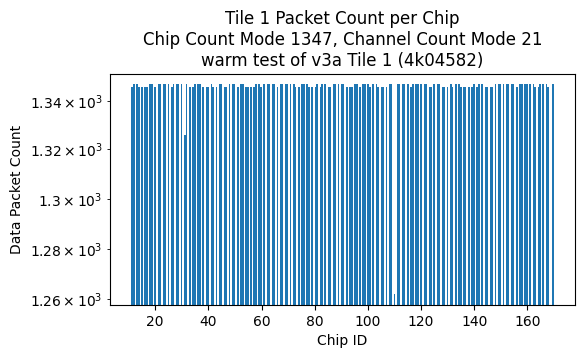

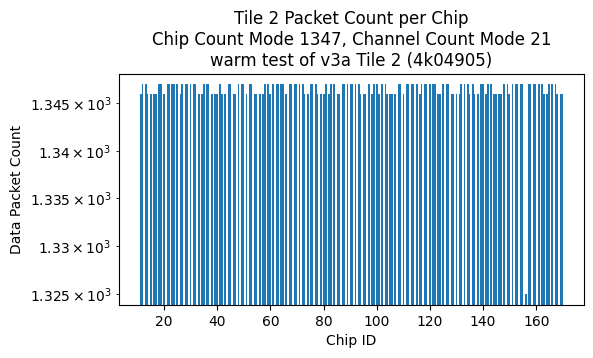

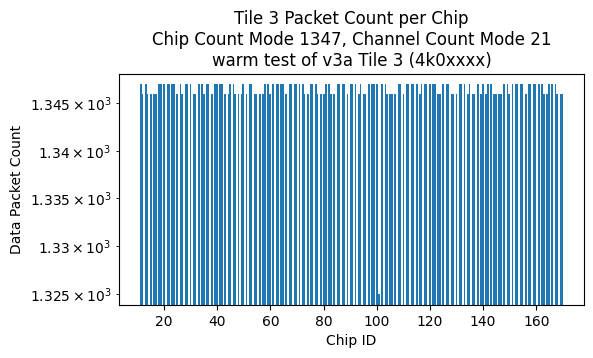

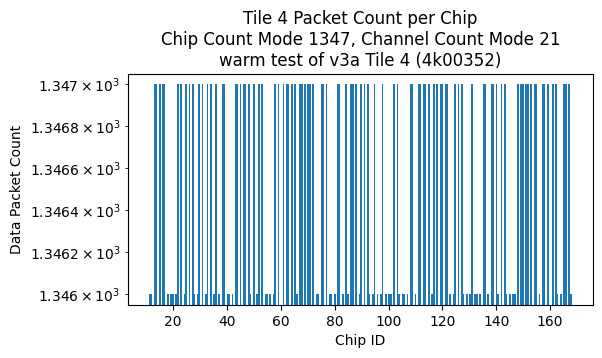

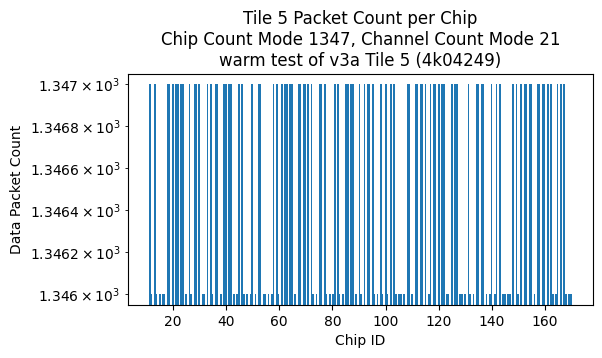

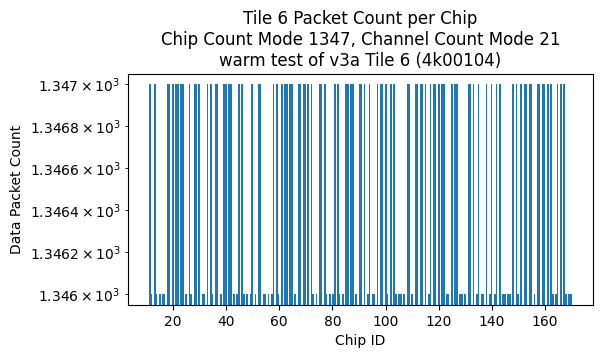

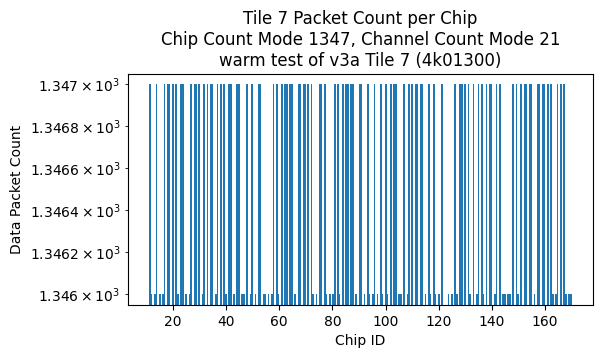

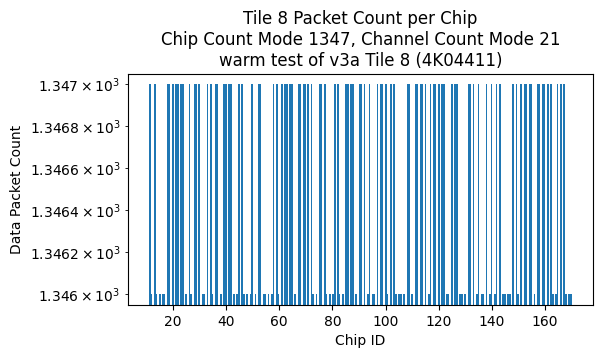

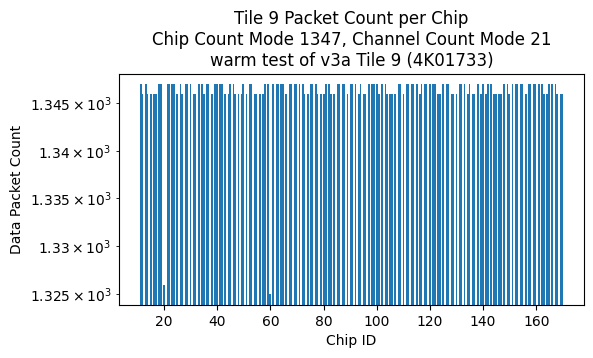

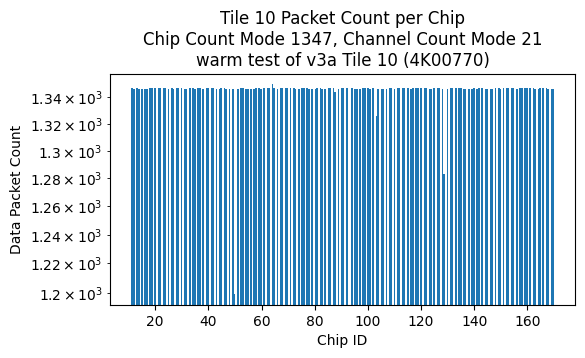

In [6]:
####################
# main
####################

# create file list of asic_config json files
files = get_files(asic_dir)

# get packets from pedestal run data file and check for various attributes
for tile in tiles:
    chip_serial_number = chip_serial_number_list[tile]
    get_data(filename, tile, ig, files)
